# Sales Performance & Forecasting Analysis

## Internship Assessment — Python & Data Science

### Project Overview

This project performs an end-to-end analysis of the Superstore retail sales dataset. The analysis includes data cleaning, exploratory data analysis, statistical analysis, and machine-learning-based sales forecasting.

### Objectives

- Clean and prepare the retail sales dataset
- Identify missing values, duplicates, and data-type issues
- Explore sales patterns using visualizations
- Analyze category-wise, region-wise, and product-wise performance
- Generate statistical summaries
- Build and evaluate sales forecasting models
- Develop actionable business recommendations

### Technologies Used

- Python 3
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

### Dataset

Superstore Sales Dataset — Kaggle

### Final Model

Random Forest Regression with time-based and seasonal features.

- RMSE: 16,094.10
- R² Score: 0.5511

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("data/train.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 9800
Columns: 18


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.shape


(9800, 18)

In [6]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [10]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
# Check data types
print("Data types:")
print(df.dtypes)

Data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [12]:
# statistical summary
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [22]:
# Handle missing Postal Codes
df["Postal Code"] = df["Postal Code"].fillna("Unknown")



In [23]:
print("Missing Postal Code values after cleaning:",
      df["Postal Code"].isnull().sum())

Missing Postal Code values after cleaning: 0


In [24]:
# Convert date columns to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print("Date conversion completed.")
print(df[["Order Date", "Ship Date"]].dtypes)

Date conversion completed.
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [25]:
# Check for missing dates after conversion
print("Missing Order Dates:", df["Order Date"].isnull().sum())
print("Missing Ship Dates:", df["Ship Date"].isnull().sum())

Missing Order Dates: 0
Missing Ship Dates: 0


In [27]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


In [28]:
# Create monthly sales data

df["YearMonth"] = df["Order Date"].dt.to_period("M")

monthly_sales = df.groupby("YearMonth")["Sales"].sum()

monthly_sales.head()

YearMonth
2015-01    14205.707
2015-02     4519.892
2015-03    55205.797
2015-04    27906.855
2015-05    23644.303
Freq: M, Name: Sales, dtype: float64

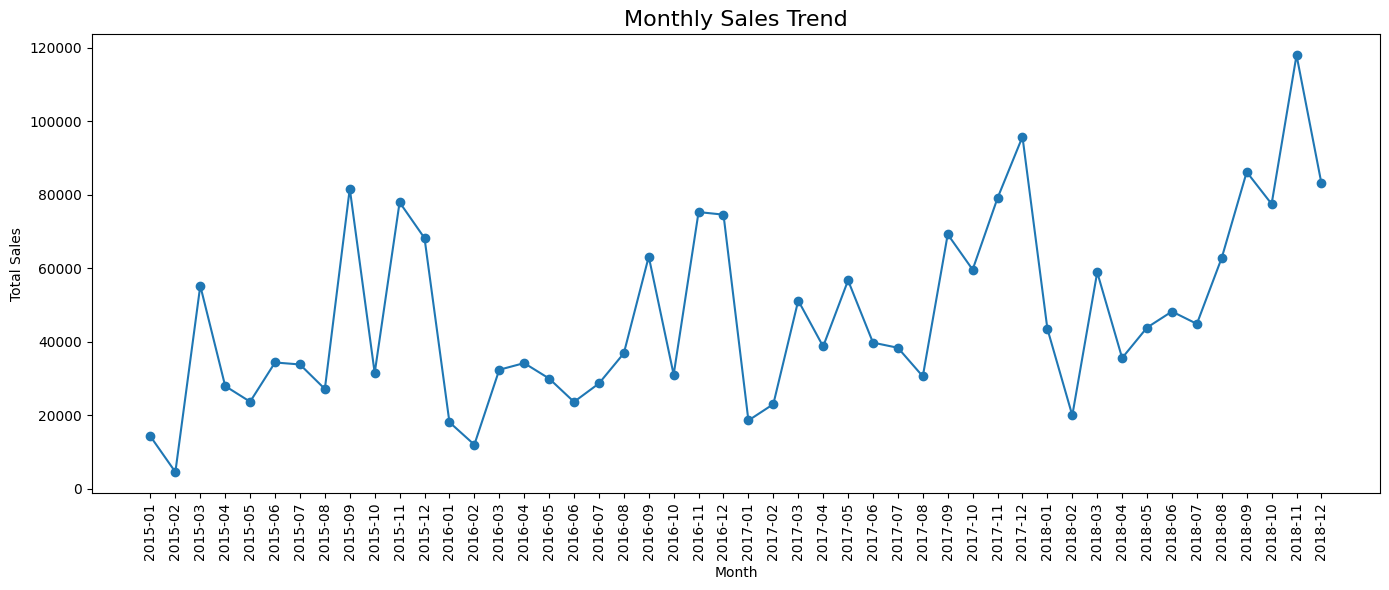

In [29]:
# Visualization 1: Monthly Sales Trend

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("outputs/monthly_sales_trend.png", dpi=300)

plt.show()

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


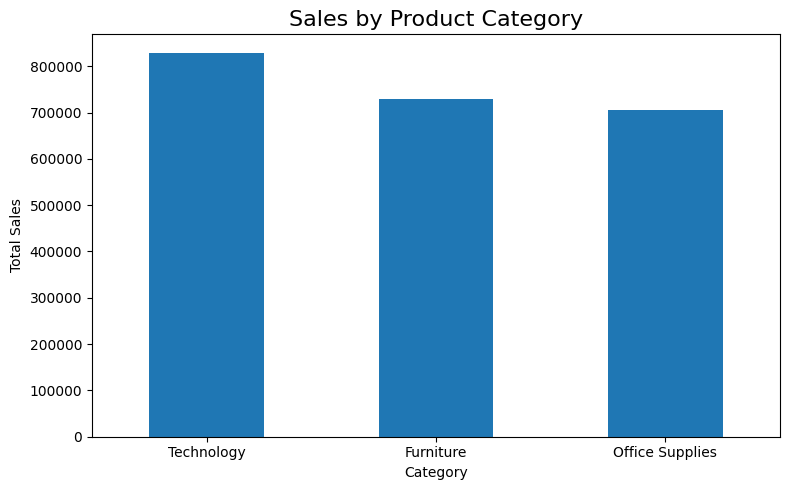

In [30]:
# Visualization 2: Sales by Category

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Sales by Product Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("outputs/category_sales.png", dpi=300)

plt.show()

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


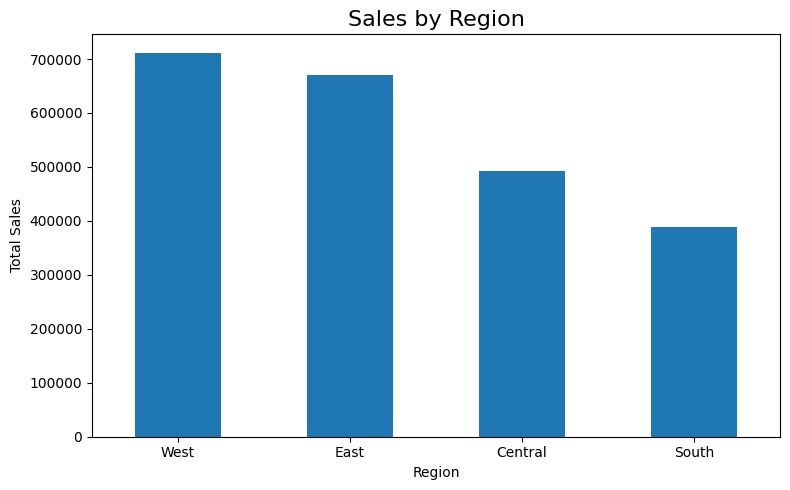

In [31]:
# Visualization 3: Sales by Region

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Sales by Region", fontsize=16)
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("outputs/region_sales.png", dpi=300)

plt.show()

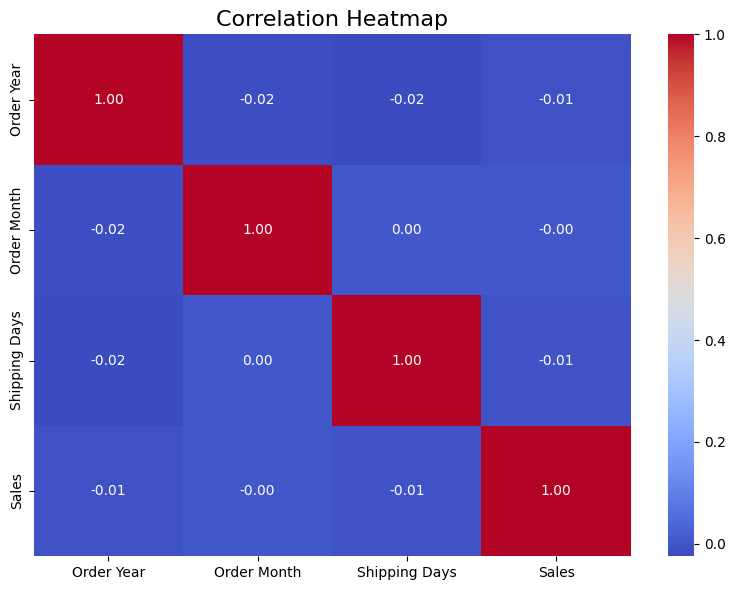

In [33]:
# Create useful numerical features for correlation analysis

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

correlation_data = df[
    ["Order Year", "Order Month", "Shipping Days", "Sales"]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()

plt.savefig("outputs/correlation_heatmap.png", dpi=300)

plt.show()

Top 10 Products by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


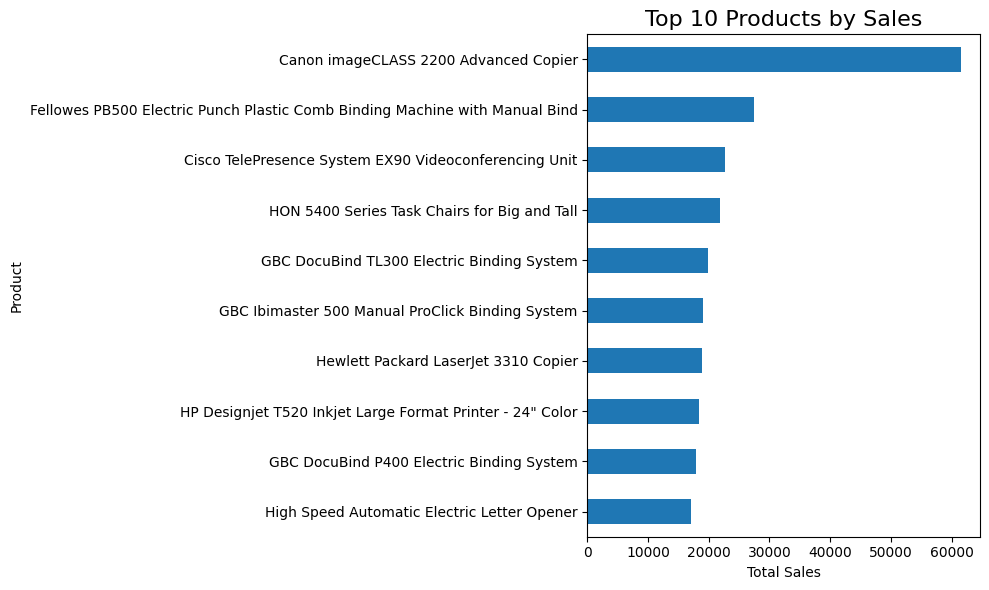

In [34]:
# Visualization 5: Top 10 Products by Sales

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Sales:")
print(top_products)

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig("outputs/top_10_products.png", dpi=300)

plt.show()

In [35]:
# Statistical summary for Sales

sales_mean = df["Sales"].mean()
sales_median = df["Sales"].median()
sales_std = df["Sales"].std()

print("Sales Statistical Summary")
print("-------------------------")
print(f"Mean Sales   : {sales_mean:.2f}")
print(f"Median Sales : {sales_median:.2f}")
print(f"Std Deviation: {sales_std:.2f}")

Sales Statistical Summary
-------------------------
Mean Sales   : 230.77
Median Sales : 54.49
Std Deviation: 626.65


In [36]:
# Additional sales statistics

print("Minimum Sales:", df["Sales"].min())
print("Maximum Sales:", df["Sales"].max())

Minimum Sales: 0.444
Maximum Sales: 22638.48


In [37]:
# Prepare monthly sales data for forecasting

monthly_df = (
    df.groupby("YearMonth")["Sales"]
    .sum()
    .reset_index()
)

monthly_df["Month_Number"] = np.arange(1, len(monthly_df) + 1)

monthly_df.head()

,YearMonth,Sales,Month_Number
0,2015-01,14205.707,1
1,2015-02,4519.892,2
2,2015-03,55205.797,3
3,2015-04,27906.855,4
4,2015-05,23644.303,5


In [38]:
# Train-test split

split_index = int(len(monthly_df) * 0.8)

train_data = monthly_df.iloc[:split_index]
test_data = monthly_df.iloc[split_index:]

X_train = train_data[["Month_Number"]]
y_train = train_data["Sales"]

X_test = test_data[["Month_Number"]]
y_test = test_data["Sales"]

print("Training months:", len(train_data))
print("Testing months:", len(test_data))

Training months: 38
Testing months: 10


In [39]:
# Train Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Model trained successfully!
Coefficient: 686.2815277492068
Intercept: 28798.621653627313


In [40]:
# Predict sales for the test period

y_pred = model.predict(X_test)

print("Actual Sales:")
print(y_test.values)

print("\nPredicted Sales:")
print(y_pred)

Actual Sales:
[ 58863.4128  35541.9101  43825.9822  48190.7277  44825.104   62837.848
  86152.888   77448.1312 117938.155   83030.3888]

Predicted Sales:
[55563.60123585 56249.8827636  56936.16429134 57622.44581909
 58308.72734684 58995.00887459 59681.29040234 60367.57193009
 61053.85345784 61740.13498559]


In [41]:
# Model evaluation

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation
----------------
RMSE: 23619.29
R² Score: 0.0332


In [42]:
# Create time-based features for improved forecasting

forecast_df = monthly_df.copy()

forecast_df["Year"] = forecast_df["YearMonth"].dt.year
forecast_df["Month"] = forecast_df["YearMonth"].dt.month

# Create cyclical month features
forecast_df["Month_Sin"] = np.sin(2 * np.pi * forecast_df["Month"] / 12)
forecast_df["Month_Cos"] = np.cos(2 * np.pi * forecast_df["Month"] / 12)

forecast_df.head()

,YearMonth,Sales,Month_Number,Year,Month,Month_Sin,Month_Cos
0,2015-01,14205.707,1,2015,1,0.500000,8.660254e-01
1,2015-02,4519.892,2,2015,2,0.866025,5.000000e-01
2,2015-03,55205.797,3,2015,3,1.000000,6.123234e-17
3,2015-04,27906.855,4,2015,4,0.866025,-5.000000e-01
4,2015-05,23644.303,5,2015,5,0.500000,-8.660254e-01


In [43]:
# Chronological train-test split

split_index = int(len(forecast_df) * 0.8)

train_data = forecast_df.iloc[:split_index]
test_data = forecast_df.iloc[split_index:]

features = [
    "Month_Number",
    "Year",
    "Month",
    "Month_Sin",
    "Month_Cos"
]

X_train = train_data[features]
y_train = train_data["Sales"]

X_test = test_data[features]
y_test = test_data["Sales"]

print("Training months:", len(train_data))
print("Testing months:", len(test_data))

Training months: 38
Testing months: 10


In [44]:
from sklearn.ensemble import RandomForestRegressor

In [45]:
# Train improved Random Forest regression model

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=5
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [46]:
# Generate predictions

rf_pred = rf_model.predict(X_test)

print("Actual Sales:")
print(y_test.values)

print("\nPredicted Sales:")
print(rf_pred)

Actual Sales:
[ 58863.4128  35541.9101  43825.9822  48190.7277  44825.104   62837.848
  86152.888   77448.1312 117938.155   83030.3888]

Predicted Sales:
[43753.0148397  38217.43594384 41269.83140213 38052.82926091
 36454.63390846 34615.1426966  73597.21440705 62390.37538565
 86866.08976125 88412.40217546]


In [47]:
# Evaluate Random Forest model

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Model Evaluation")
print("--------------------------------")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")

Random Forest Model Evaluation
--------------------------------
RMSE: 16094.10
R² Score: 0.5511


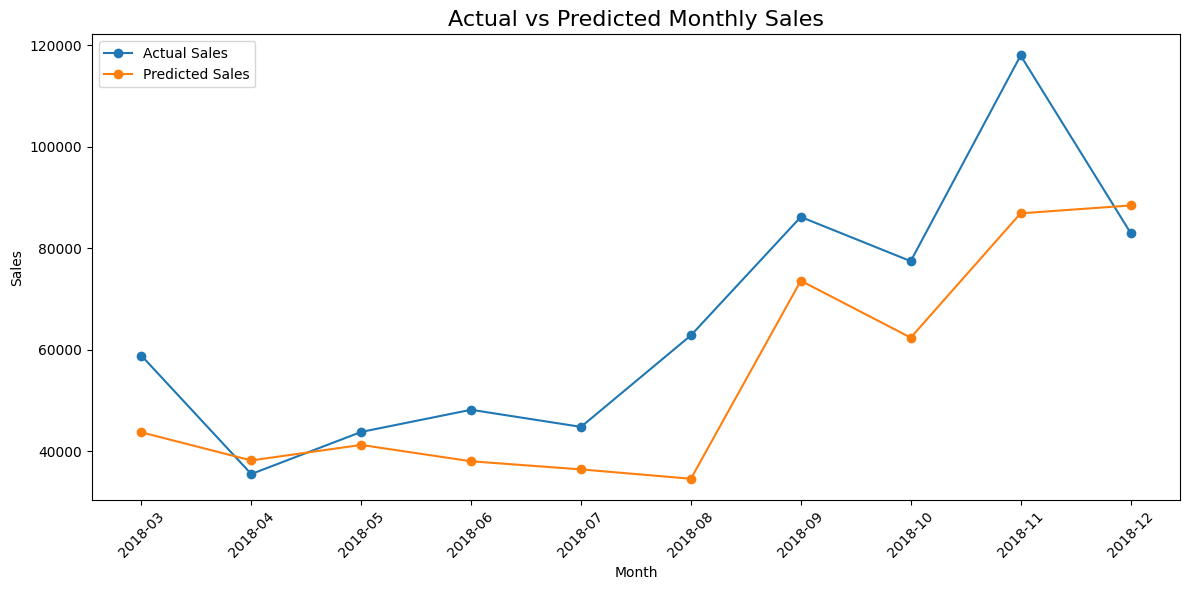

In [48]:
# Visualization 6: Actual vs Predicted Sales

plt.figure(figsize=(12, 6))

plt.plot(
    test_data["YearMonth"].astype(str),
    y_test.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test_data["YearMonth"].astype(str),
    rf_pred,
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Monthly Sales", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()

plt.savefig("outputs/actual_vs_predicted.png", dpi=300)

plt.show()

In [49]:
# Final Business Insights

print("===== BUSINESS PERFORMANCE SUMMARY =====\n")

# Category
best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

# Region
best_region = region_sales.idxmax()
best_region_sales = region_sales.max()

# Product
best_product = top_products.idxmax()
best_product_sales = top_products.max()

# Best and worst month
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

worst_month = monthly_sales.idxmin()
worst_month_sales = monthly_sales.min()

print(f"1. Best-performing category: {best_category}")
print(f"   Total Sales: {best_category_sales:,.2f}\n")

print(f"2. Best-performing region: {best_region}")
print(f"   Total Sales: {best_region_sales:,.2f}\n")

print(f"3. Top-selling product: {best_product}")
print(f"   Total Sales: {best_product_sales:,.2f}\n")

print(f"4. Highest-sales month: {best_month}")
print(f"   Total Sales: {best_month_sales:,.2f}\n")

print(f"5. Lowest-sales month: {worst_month}")
print(f"   Total Sales: {worst_month_sales:,.2f}")

===== BUSINESS PERFORMANCE SUMMARY =====

1. Best-performing category: Technology
   Total Sales: 827,455.87

2. Best-performing region: West
   Total Sales: 710,219.68

3. Top-selling product: Canon imageCLASS 2200 Advanced Copier
   Total Sales: 61,599.82

4. Highest-sales month: 2018-11
   Total Sales: 117,938.15

5. Lowest-sales month: 2015-02
   Total Sales: 4,519.89


# Conclusion

The Sales Performance & Forecasting Analysis identified important patterns in the Superstore dataset. Technology was the highest-performing category, while the West was the strongest region. Sales showed substantial variation across months, with November 2018 recording the highest monthly sales.

Two regression approaches were evaluated. The initial Linear Regression model produced an R² score of 0.0332, while the improved Random Forest model using time and seasonal features achieved an R² score of 0.5511 and an RMSE of 16,094.10.

The results demonstrate that incorporating time-based and seasonal information can improve sales forecasting. The findings can support inventory planning, regional marketing strategies, product prioritization, and preparation for high-demand periods.

Future improvements could include incorporating additional variables such as product category, customer segment, discounts, shipping mode, and historical lagged sales to improve forecasting performance.